In [3]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [4]:
def get_infect_prob(contact_rate, Beta, days_infectious):
    numerator = contact_rate / (1 - contact_rate) * np.exp(Beta * (days_infectious**3 - 1))
    return numerator / (1 + numerator)

In [7]:
class Agent:
    def __init__(self, node_id, initial_state='B'):
        self.node_id = node_id
        self.state = initial_state
        self.next_state = initial_state

    def compute_next_state(self, G, agent_map, threshold_type, threshold_val, debug=False):
        if self.state == 'A':
            return
            
        neighbors = list(G.neighbors(self.node_id))
        if not neighbors:
            return
            
        a_count = sum(1 for n in neighbors if agent_map[n].state == 'A')
        
        if debug:
            print(f"DEBUG: Node {self.node_id} has {a_count} 'A' neighbors out of {len(neighbors)}.")
            
        if threshold_type == 'absolute':
            if a_count >= threshold_val:
                self.next_state = 'A'
        elif threshold_type == 'fractional':
            fraction = a_count / len(neighbors)
            if fraction >= threshold_val:
                self.next_state = 'A'

    def update_state(self):
        self.state = self.next_state

In [29]:
class Population:
    def __init__(self, G, early_adopters, threshold_type='absolute', threshold_val=2):
        """Initialize population and networks."""
        self.G = G
        self.threshold_type = threshold_type
        self.threshold_val = threshold_val
        self.history = {'A': [], 'B': []}
        self.agent_map = {}
        
        for node_id in G.nodes():
            state = 'A' if node_id in early_adopters else 'B'
            self.agent_map[node_id] = Agent(node_id, state)
            
        self.record_history()

    def record_history(self):
        a_count = sum(1 for agent in self.agent_map.values() if agent.state == 'A')
        b_count = len(self.agent_map) - a_count
        self.history['A'].append(a_count)
        self.history['B'].append(b_count)

    def update(self, debug=False):
        # Compute next state
        for agent in self.agent_map.values():
            agent.compute_next_state(self.G, self.agent_map, self.threshold_type, self.threshold_val, debug=debug)
            
        # Apply new state
        for agent in self.agent_map.values():
            agent.update_state()
            
        self.record_history()

    def draw(self, pos=None, title=""):
        if pos is None:
            pos = nx.spring_layout(self.G)
            
        color_map = {'A': 'red', 'B': 'blue'}
        node_colors = [color_map[self.agent_map[node_id].state] for node_id in self.G.nodes()]
        
        plt.figure(figsize=(8, 6))
        nx.draw(self.G, pos, node_color=node_colors, with_labels=True, 
                node_size=300, font_color="white", font_weight="bold")
        plt.title(title)
        plt.show()

In [30]:
def get_graph_nineteenfour_from_NCM_book():
    """Create the graph from Figure 19.4 of the NCM book."""
    G = nx.Graph()
    G.add_nodes_from(range(1, 18))
    G.add_edges_from([(1,2), (1,3),(2,3),(2,6), (4,5), (4,6), (4,7), (5,7), (5,8), (6,9), (7,8), (7,9), (7,10)])
    G.add_edges_from([(8,10), (8,14), (9,10), (9,11), (10,12), (11,12), (11,15), (12, 13), (12, 15), (12,16)])
    G.add_edges_from([(13,14), (13,16), (13,17), (14,17), (15,16), (16,17)])
    return G

In [31]:
networks = {
    "Fig19.4": get_graph_nineteenfour_from_NCM_book(),
    "Circ20-2": nx.circulant_graph(20, [1, 2]),
    "Circ20-4": nx.circulant_graph(20, [1, 2, 3, 4]),
    "Karate": nx.relabel_nodes(nx.karate_club_graph(), lambda x: x + 1),
    "Scale100": nx.barabasi_albert_graph(100, 2),
    "Scale410": nx.barabasi_albert_graph(410, 2),
    "SmallWorld100": nx.watts_strogatz_graph(100, 5, 0.3),
    "SmallWorld410": nx.watts_strogatz_graph(410, 3, 0.3),
    "Dublin": nx.Graph(mmread('ia-infect-dublin.mtx'))
}

In [32]:
def run_cascade(network, early_adopters, threshold_type, threshold_val, debug=False, draw_steps=False):
    # Run until cascade stops
    pop = Population(network, early_adopters, threshold_type, threshold_val)
    
    if draw_steps:
        pos = nx.kamada_kawai_layout(network)
        pop.draw(pos, title="Initial State (t=0)")
        
    t = 0
    while True:
        prev_A = pop.history['A'][-1]
        pop.update(debug=debug)
        t += 1
        
        if draw_steps and pop.history['A'][-1] != prev_A:
            pop.draw(pos, title=f"Time Step {t}")
            
        if pop.history['A'][-1] == prev_A:
            break
            
    return pop.history

In [51]:
def run_random_graph_trials(generator_func, num_trials=10, selection_strategy='highest_degree', num_adopters=4, threshold_type='absolute', threshold_val=2, debug=False):
    histories = []
    last_G = None
    
    for i in range(num_trials):
        if debug:
            print(f"DEBUG: Starting random graph trial {i+1} of {num_trials}.")
            
        # Generate graph.
        G_trial = generator_func()
        last_G = G_trial
        
        # Select early adopters.
        degrees = dict(G_trial.degree())
        sorted_nodes = sorted(degrees, key=degrees.get)
        
        if selection_strategy == 'highest_degree':
            early_adopters = sorted_nodes[-num_adopters:]
        elif selection_strategy == 'lowest_degree':
            early_adopters = sorted_nodes[:num_adopters]
        else:
            raise ValueError(f"Unknown selection strategy: {selection_strategy}")
            
        # Run simulation.
        trial_history = run_cascade(G_trial, early_adopters, threshold_type, threshold_val, debug=debug)
        histories.append(trial_history)
        
    return histories, last_G

In [52]:
def plot_adoption_curve(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history['A'], label="Adopted (A)", color="red", linewidth=2)
    plt.plot(history['B'], label="Baseline (B)", color="blue", linewidth=2)
    plt.title(title)
    plt.xlabel("Time Step")
    plt.ylabel("Number of Agents")
    
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_multiple_trials(histories, title):
    max_len = max(len(h['A']) for h in histories)
    padded_A = []
    
    for h in histories:
        pad_len = max_len - len(h['A'])
        padded_A.append(h['A'] + [h['A'][-1]] * pad_len)
        
    A_matrix = np.array(padded_A)
    mean_A = np.mean(A_matrix, axis=0)
    p25_A = np.percentile(A_matrix, 25, axis=0)
    p75_A = np.percentile(A_matrix, 75, axis=0)
    
    plt.figure(figsize=(8, 5))
    plt.plot(mean_A, label="Mean Adopted (A)", color="cyan", linewidth=2)
    plt.fill_between(range(max_len), p25_A, p75_A, color="cyan", alpha=0.3, label="Interquartile Range")
    plt.title(title)
    plt.xlabel("Time Step")
    plt.ylabel("Number of Agents")
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.legend()
    plt.grid(True)
    plt.show()


def summarize_results(network_name, G, histories):
    times_to_stop = [len(h['A']) - 1 for h in histories]
    avg_time = np.mean(times_to_stop)
    std_time = np.std(times_to_stop)
    
    n_nodes = G.number_of_nodes()
    pct_adopted = [(h['A'][-1] / n_nodes) * 100 for h in histories]
    avg_pct = np.mean(pct_adopted)
    std_pct = np.std(pct_adopted)
    
    clustering_coeff = nx.average_clustering(G)
    density = nx.density(G)
    
    avg_path = nx.average_shortest_path_length(G)
        
    return {
        "Network": network_name,
        "Avg Time to Stop": round(avg_time, 2),
        "Std Time to Stop": round(std_time, 2),
        "Avg % Adopted": round(avg_pct, 2),
        "Std % Adopted": round(std_pct, 2),
        "Clustering Coeff": round(clustering_coeff, 4),
        "Density": round(density, 4),
        "Avg Path Length": round(avg_path, 4)
    }


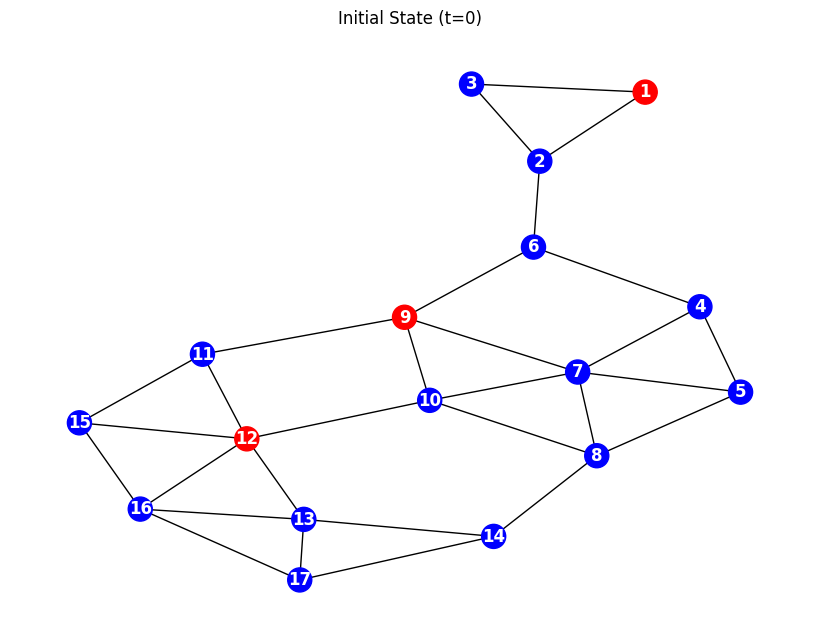

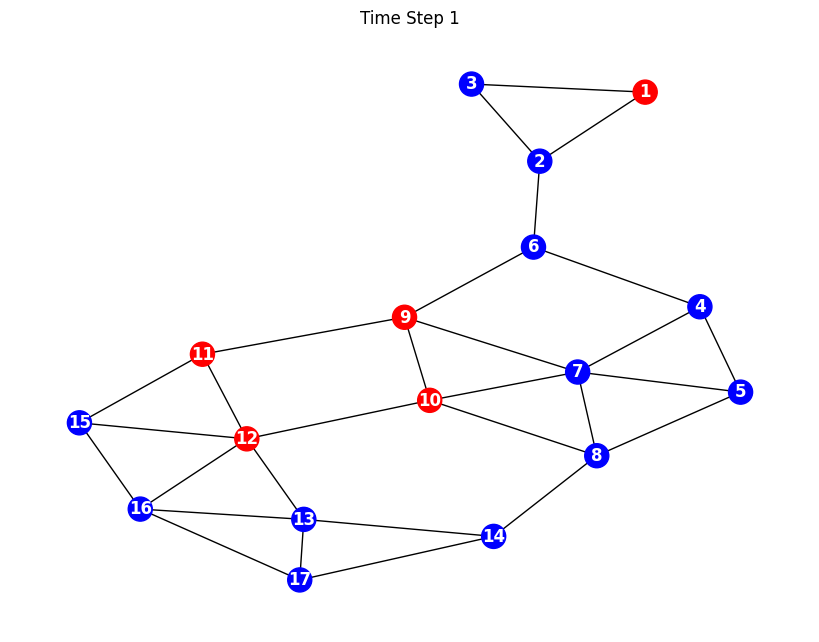

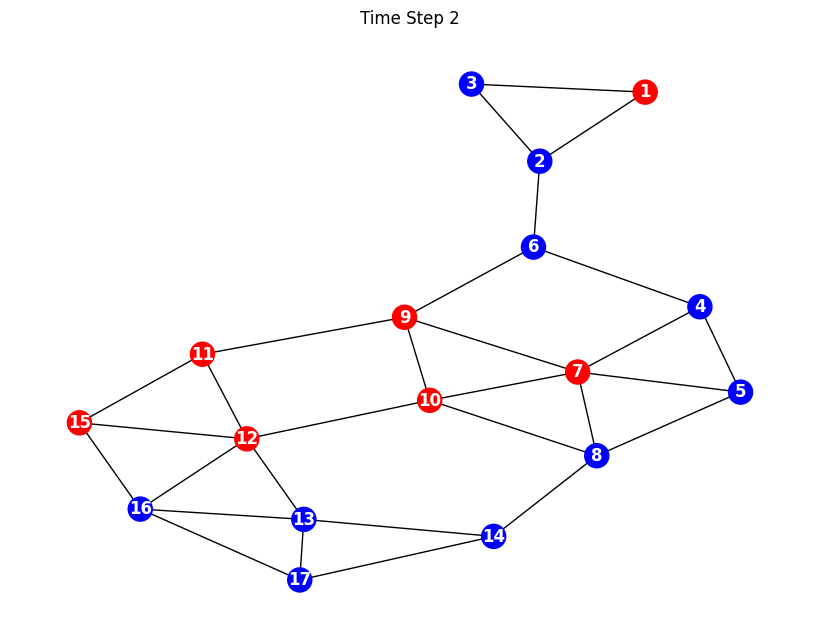

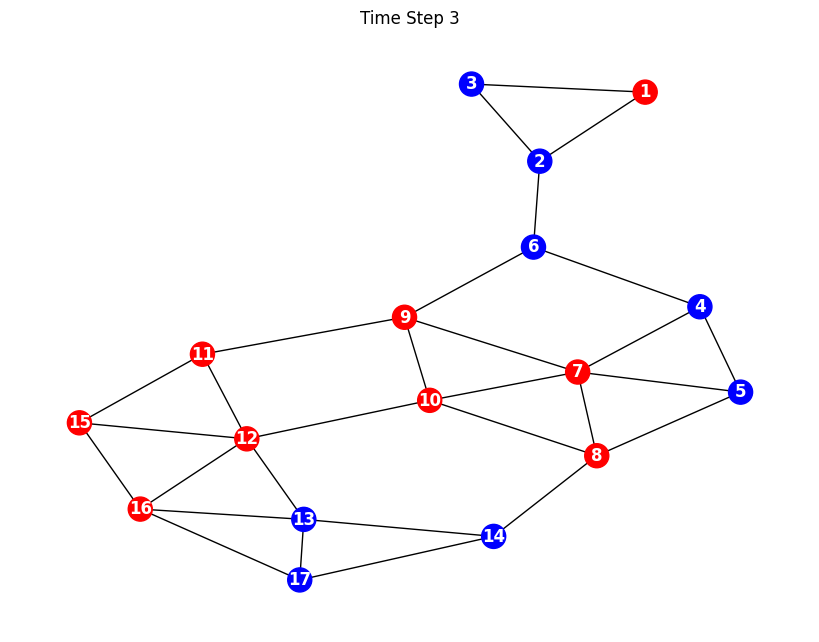

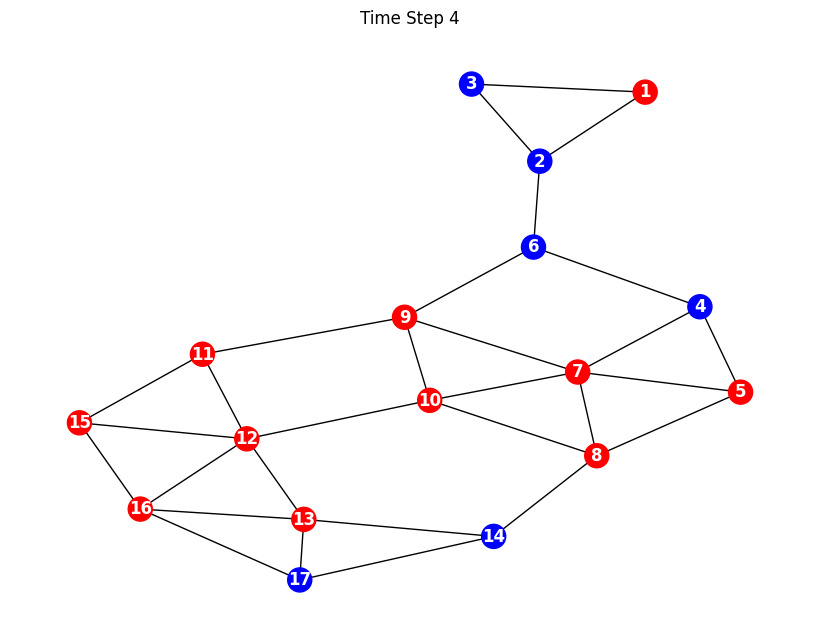

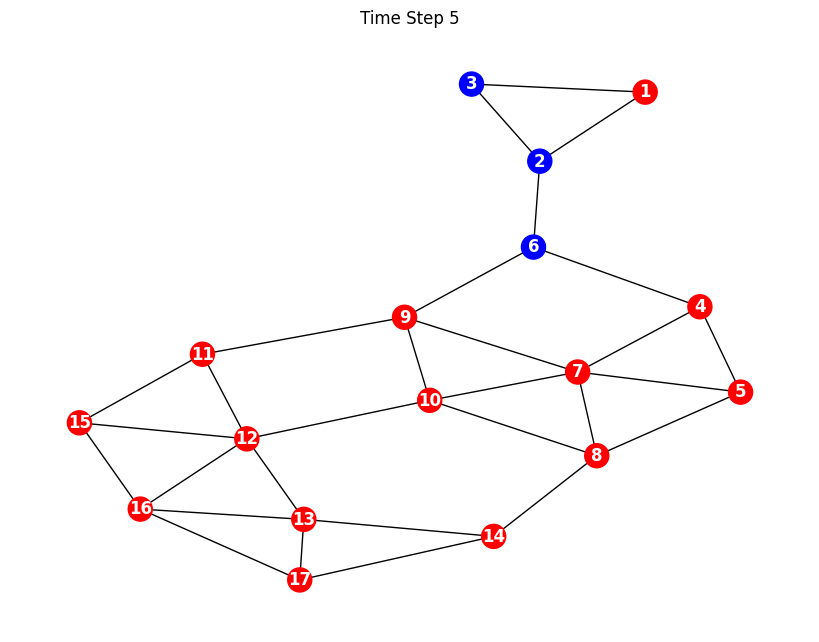

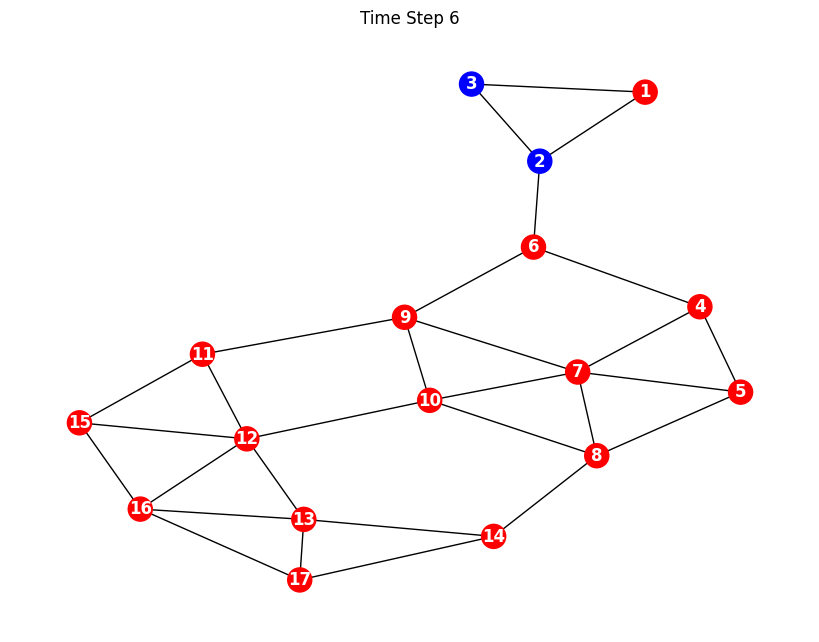

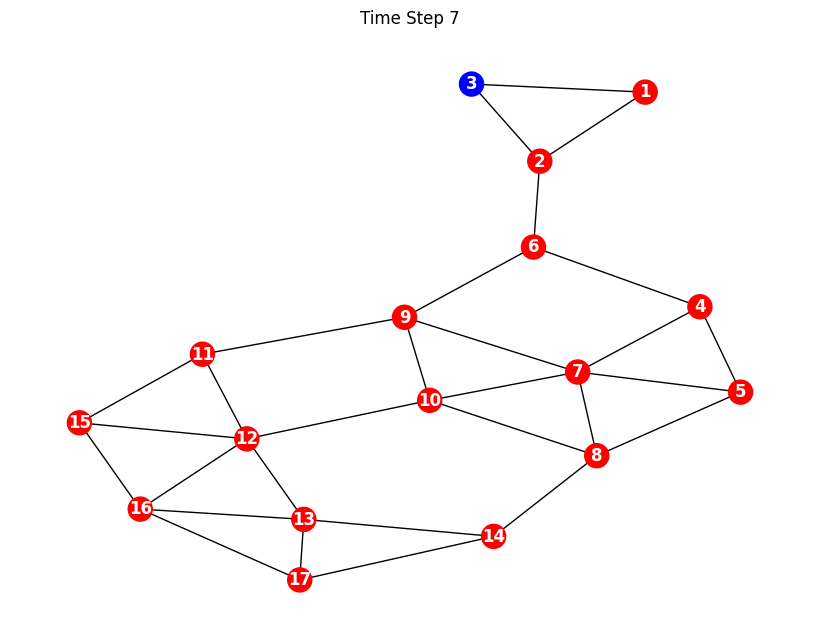

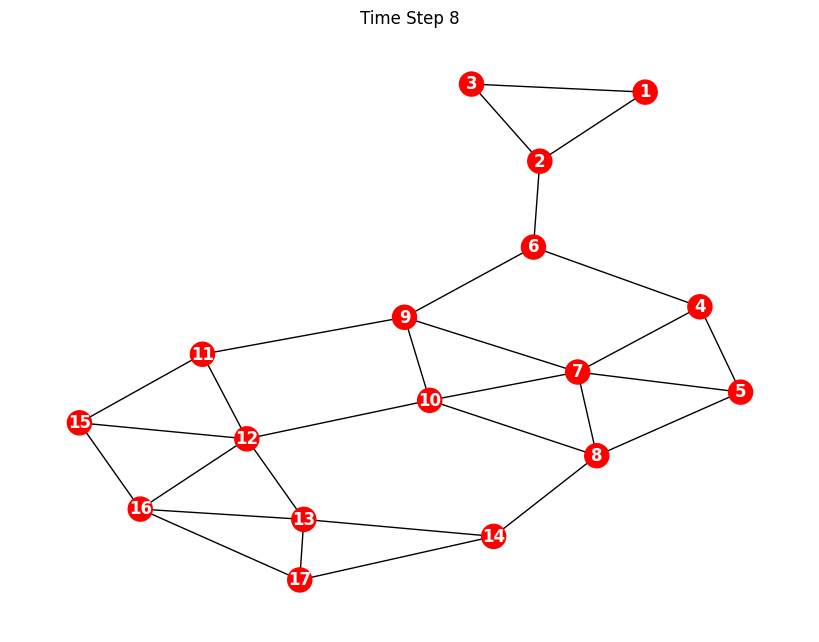

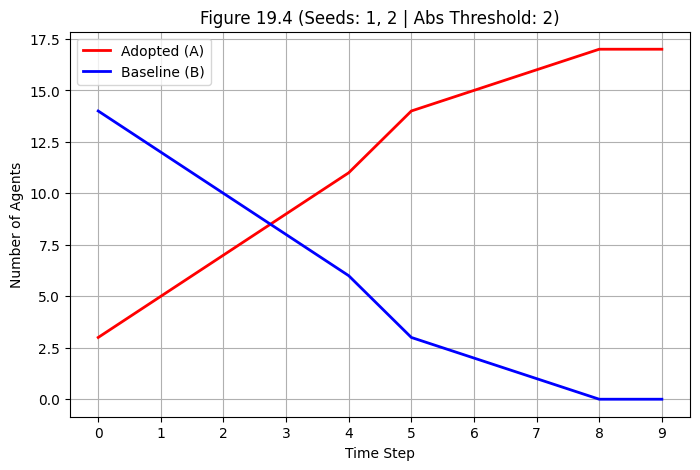

Final A count: 17 / 17


In [50]:
history = run_cascade(
    network=networks["Fig19.4"], 
    early_adopters=[12, 9, 1], 
    threshold_type='absolute', 
    threshold_val=2,
    draw_steps=True
)
plot_adoption_curve(history, "Figure 19.4 (Seeds: 1, 2 | Abs Threshold: 2)")
print(f"Final A count: {history['A'][-1]} / {G.number_of_nodes()}")
